# linear modelでのいくつかの実験

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# =========================
# Simple finite-M experiment
# (fixed D, N; vary M)
# =========================
D = 50

NM_LIST = [
    (30, 200),
    (10, 10_000),
    (30, 10_000),
    (100, 10_000),
    (200, 10_000),
    (400, 10_000),
    (600, 10_000),
]
BATCH_SIZE = 500
ADAM_LR = 1e-3
PARAM_L2_LAMBDA = 0.0001
ITERATIONS = 3000
EVAL_T_LIST = list(range(0, 22))
EVAL_BATCH_SIZE = 2048
SEED = 120
N_TRIALS = 1  # 同一設定での繰り返し回数（SE算出用）

DE = 2 * D + 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(
    f"device={device}, "
    f"B={BATCH_SIZE}, iters={ITERATIONS}, lr={ADAM_LR}, l2={PARAM_L2_LAMBDA}, "
    f"trials={N_TRIALS}"
)


def sample_task_batch(batch_size, n, d=D, device=device):
    x = torch.randn(batch_size, d, n, device=device)
    w_star = torch.randn(batch_size, d, device=device)
    y = torch.einsum("bd,bdn->bn", w_star, x)
    return x, y, w_star


def build_fixed_train_dataset(m, n):
    x, y, w_star = sample_task_batch(m, n=n)
    return {"X": x, "y": y, "w_star": w_star, "M": m, "N": n}


def sample_train_minibatch(train_data, batch_size=BATCH_SIZE):
    idx = torch.randint(0, train_data["M"], (batch_size,), device=device)
    return train_data["X"][idx], train_data["y"][idx], train_data["w_star"][idx]


def sample_w0_random(x, d=D, device=device):
    # Initial estimate is random normal (requested setting).
    return torch.randn(x.shape[0], d, device=device)


def build_Z(x, y, w_prefix):
    b, d, n = x.shape
    i = len(w_prefix) - 1
    t = n + i + 1
    z = torch.zeros(b, DE, t, device=x.device)
    z[:, :d, :n] = x
    z[:, d, :n] = y
    for step, w_t in enumerate(w_prefix):
        z[:, d + 1 : d + 1 + d, n + step] = w_t
    z[:, -1, -1] = 1.0
    return z


def build_data_src_mask(t, n, device):
    mask = torch.zeros(t, device=device)
    mask[:n] = 1.0
    return mask


def f_lsa_last(z, v, w, n, src_mask=None):
    z_last = z[:, :, -1]
    wz = torch.einsum("ij,bj->bi", w, z_last)
    scores = torch.einsum("bdt,bd->bt", z, wz) / n
    if src_mask is not None:
        if src_mask.dim() == 1:
            src_mask = src_mask.unsqueeze(0)
        scores = scores * src_mask
    weighted = torch.einsum("bdt,bt->bd", z, scores)
    out_last = z_last + torch.einsum("ij,bj->bi", v, weighted)
    return out_last


def no_cot_train_loss(v, w, x, y, w_star):
    n = x.shape[2]
    w0 = sample_w0_random(x, D, x.device)
    z0 = build_Z(x, y, [w0])
    src_mask = build_data_src_mask(z0.shape[2], n=n, device=z0.device)
    pred = f_lsa_last(z0, v, w, n=n, src_mask=src_mask)
    w_hat = pred[:, D + 1 : D + 1 + D]
    return 0.5 * ((w_hat - w_star) ** 2).sum(dim=1).mean()


def eval_dynamics_curve(v, w, n, t_list, batch_size=EVAL_BATCH_SIZE):
    x, y, w_star = sample_task_batch(batch_size, n=n)
    with torch.no_grad():
        w_hat = sample_w0_random(x, D, device)
        losses = {}
        losses[0] = ((w_hat - w_star) ** 2).mean(dim=1).mean().item()
        max_t = max(t_list)
        for t in range(1, max_t + 1):
            z = build_Z(x, y, [w_hat])
            src_mask = build_data_src_mask(z.shape[2], n=n, device=z.device)
            pred = f_lsa_last(z, v, w, n=n, src_mask=src_mask)
            w_hat = pred[:, D + 1 : D + 1 + D]
            losses[t] = ((w_hat - w_star) ** 2).mean(dim=1).mean().item()
    return {t: losses[t] for t in t_list}


def parameter_l2_penalty(v, w):
    return v.pow(2).sum() + w.pow(2).sum()


def train_model_no_cot_finite(train_data, iterations=ITERATIONS):
    v = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    w = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    opt = torch.optim.Adam([v, w], lr=ADAM_LR)

    for _ in range(iterations):
        x, y, w_star = sample_train_minibatch(train_data, BATCH_SIZE)
        data_loss = no_cot_train_loss(v, w, x, y, w_star)
        reg_loss = PARAM_L2_LAMBDA * parameter_l2_penalty(v, w)
        loss = data_loss + reg_loss

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

    return v.detach(), w.detach()

device=cpu, B=500, iters=3000, lr=0.001, l2=0.0001, trials=1


In [2]:
np.random.seed(SEED)
torch.manual_seed(SEED)

results_by_nm = {}
for n, m in NM_LIST:
    trial_curves = []

    for trial in range(N_TRIALS):
        # (N, M)ごとに同じ乱数系列を使わないように試行seedを分離
        trial_seed = SEED + 1000 * trial + 17 * n + m
        np.random.seed(trial_seed)
        torch.manual_seed(trial_seed)

        train_data = build_fixed_train_dataset(m, n)
        v_tr, w_tr = train_model_no_cot_finite(train_data)
        eval_curve = eval_dynamics_curve(v_tr, w_tr, n=n, t_list=EVAL_T_LIST)
        trial_curves.append(np.array([eval_curve[t] for t in EVAL_T_LIST]))

    trial_curves = np.stack(trial_curves, axis=0)  # [trials, len(t)]
    mean_curve = trial_curves.mean(axis=0)
    se_curve = trial_curves.std(axis=0, ddof=1) / np.sqrt(N_TRIALS)

    results_by_nm[(n, m)] = {
        "mean": {t: float(mean_curve[i]) for i, t in enumerate(EVAL_T_LIST)},
        "se": {t: float(se_curve[i]) for i, t in enumerate(EVAL_T_LIST)},
        "all": trial_curves,
    }

    print(f"N={n}, M={m}: done ({N_TRIALS} trials)")


/home/takanami/miniforge3/envs/py312/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/takanami/miniforge3/envs/py312/lib/python3.12/site-packages/numpy/_core/_methods.py:208: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


N=30, M=200: done (1 trials)
N=10, M=10000: done (1 trials)
N=30, M=10000: done (1 trials)
N=100, M=10000: done (1 trials)
N=200, M=10000: done (1 trials)
N=400, M=10000: done (1 trials)
N=600, M=10000: done (1 trials)


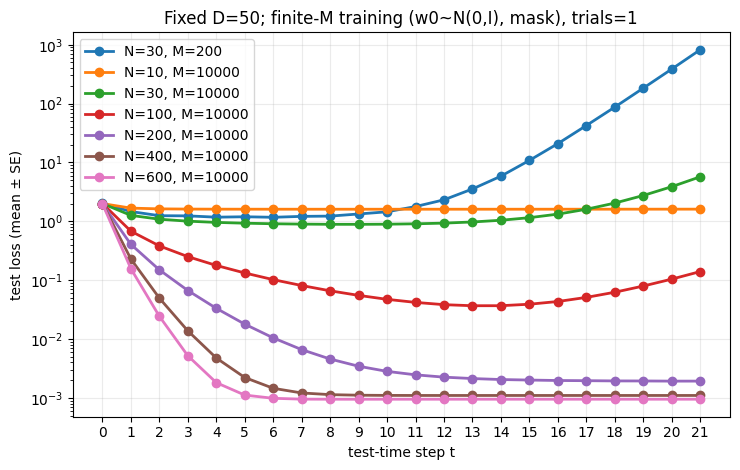

In [3]:
plt.figure(figsize=(7.5, 4.8))
for n, m in NM_LIST:
    ts = np.array(EVAL_T_LIST)
    mean_vals = np.array([results_by_nm[(n, m)]["mean"][t] for t in ts])
    se_vals = np.array([results_by_nm[(n, m)]["se"][t] for t in ts])

    plt.plot(ts, mean_vals, marker="o", linewidth=2, label=f"N={n}, M={m}")
    plt.fill_between(ts, mean_vals - se_vals, mean_vals + se_vals, alpha=0.18)

plt.xlabel("test-time step t")
plt.ylabel("test loss (mean ± SE)")
plt.title(f"Fixed D={D}; finite-M training (w0~N(0,I), mask), trials={N_TRIALS}")
plt.xticks(EVAL_T_LIST)
plt.grid(alpha=0.25)
#plt.ylim(0, 3.0)
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()